######
Aim to understand the influnce of various factors like econimic, personal and social on the sturdents preformance

#### inferences would be:

* How to improve the students performance in each test?
* what are the major factors influencing the test scores?
* Effectivness of test preparation course?
* Other inferences

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style= 'darkgrid')

###### 
Let us initialize the required values (we will use them later in the program)

######
we will set the minimum marks to 40 to pass in a exam

In [3]:
passmark = 40

In [4]:
df = pd.read_csv('StudentsPerformance.csv')

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

######
let us understand about the basic information of the data, like min, max, mean and standard deviation etc.

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


* the mean of the courses scores under 70.
* best performance in reading exam.

In [8]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

* no miss values in this data

######
let us explore the math score first

In [9]:
math_scores = df['math score'].value_counts().reset_index()
math_scores.style.background_gradient(cmap= 'Reds', subset=['count'])

,math score,count
0,65,36
1,62,35
2,69,32
3,59,32
4,73,27
5,61,27
6,71,26
7,67,26
8,63,26
9,68,26


* The distribution is centered around mid-60s — not too high, not too low
* Scores taper off gradually on both ends — no weird spikes
* Very few perfect scores (only 7 students got 100)
* A small group scored very low (0, 8, 18, etc.) — worth checking if these are outliers

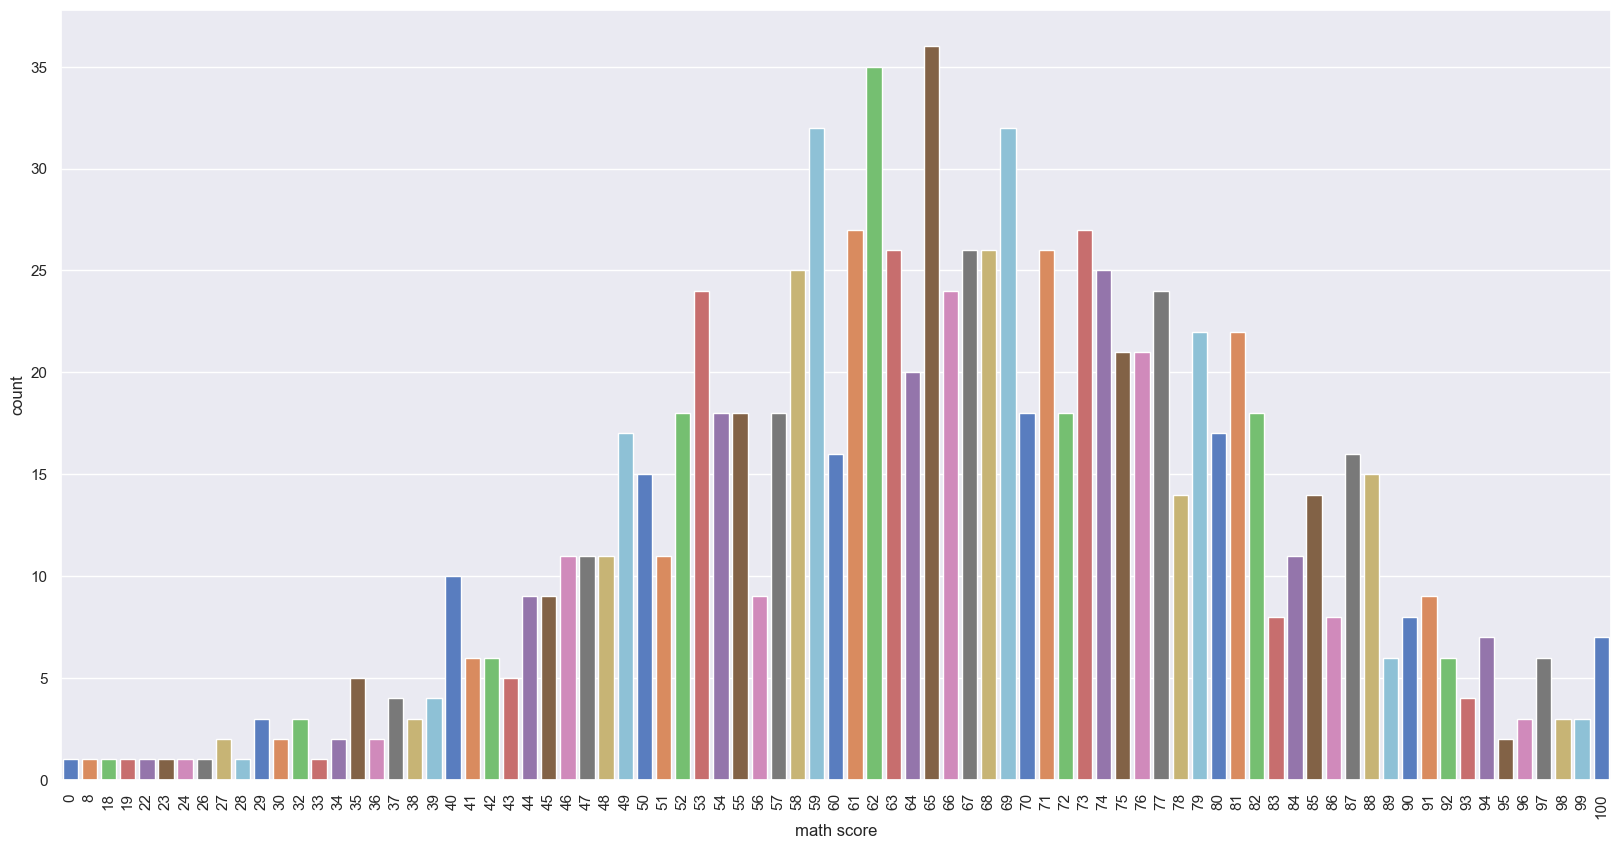

In [10]:
plt.figure(figsize= (20, 10))
sns.countplot(x = 'math score', data = df, palette= 'muted', hue = 'math score', legend= False)
plt.xticks(rotation = 90)
plt.show()

* Math performance is normally distributed - typical pattern for test scores
* Most students are average performers (50-80 range)
* The test appears to differentiate well between different ability levels
* No unusual spikes or weird patterns in the data

######
How many students passed in math exam?

In [11]:
df['math_pass_status'] = np.where(df['math score'] < passmark, 'F', 'P')
df.math_pass_status.value_counts().reset_index()

,math_pass_status,count
0,P,960
1,F,40


* Very high pass rate: 96% of students passed math
* Small fail group: Only 40 students (4%) failed — matches the low scores (0-39) we saw earlier
* Clear majority: Almost all students met the passing threshold

In [33]:
is_passed = df.groupby('parental level of education')['math_pass_status'] \
    .value_counts().reset_index() \
    .sort_values(by='count', ascending=False) \
    .reset_index(drop=True)
is_passed['pass_rates'] = is_passed['count'] / is_passed.groupby('parental level of education')['count'].transform('sum') * 100
is_passed.style.background_gradient(cmap = 'Greens', subset = ['count', 'pass_rates'])

,parental level of education,math_pass_status,count,pass_rates
0,some college,P,220,97.345133
1,associate's degree,P,219,98.648649
2,high school,P,182,92.857143
3,some high school,P,166,92.737430
4,bachelor's degree,P,114,96.610169
5,master's degree,P,59,100.000000
6,high school,F,14,7.142857
7,some high school,F,13,7.262570
8,some college,F,6,2.654867
9,bachelor's degree,F,4,3.389831


* Higher education = higher pass rates: Parents with master's/bachelor's degrees have kids with 96-100% pass rates
* Master's degree is perfect: 59 students, 0 failures
* High school & some high school: Lowest pass rates (~93%) and most of the 40 failures
* Associate's degree performs well: 98.6% pass rate — even higher than bachelor's
* Most students: Come from parents with "some college" or "associate's degree" (448 of 1,000)

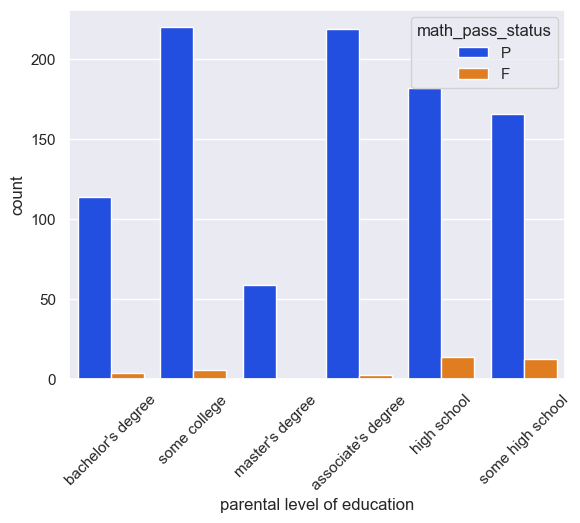

In [38]:
sns.countplot(x = 'parental level of education', data = df, hue = 'math_pass_status', palette = 'bright')
plt.xticks(rotation = 45)
plt.show()

* Parents with associate's/master's degrees → Kids almost always pass math
* Parents with high school or less → Higher chance of failing math
* Largest student groups come from parents with "some college" or "associate's degree"
* Education matters: Higher parental education = lower failure rates

######
Let us explore the Reading Scores

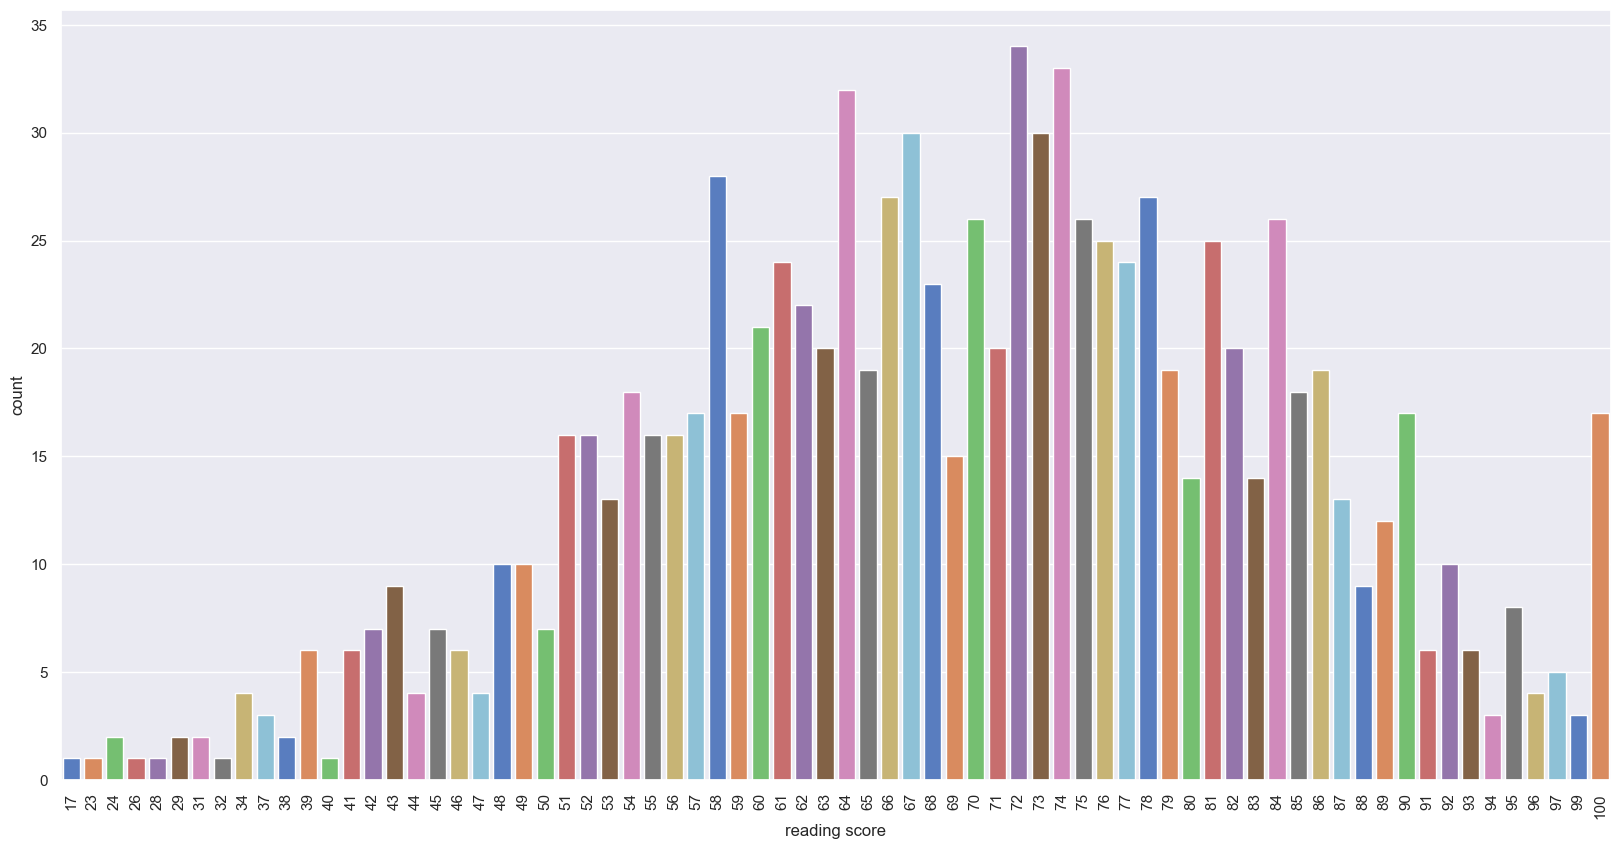

In [14]:
plt.figure(figsize= (20, 10))
sns.countplot(x = 'reading score', data = df, palette= 'muted', hue = 'reading score', legend= False)
plt.xticks(rotation = 90)
plt.show()

* Students generally find Reading easier than Math.
* The test differentiates well, but most students are performing at a good level (C to A range).

######
How many students passed in reading?

In [15]:
df['reading_pass_status'] = np.where(df['reading score'] < passmark, 'F', 'P')
df.reading_pass_status.value_counts().reset_index()

,reading_pass_status,count
0,P,974
1,F,26


* Very high pass rate: 97.4% of students passed reading
* Small fail group: Only 26 students (2.6%) failed
* Better than Math: Reading pass rate (97.4%) is higher than Math (96%)

In [39]:
is_passed = df.groupby('parental level of education')['reading_pass_status'] \
    .value_counts().reset_index() \
    .sort_values(by='count', ascending=False) \
    .reset_index(drop=True)
is_passed['pass_rates'] = is_passed['count'] / is_passed.groupby('parental level of education')['count'].transform('sum') * 100
is_passed.style.background_gradient(cmap = 'Greens', subset = ['count', 'pass_rates'])

,parental level of education,reading_pass_status,count,pass_rates
0,associate's degree,P,220,99.099099
1,some college,P,219,96.902655
2,high school,P,189,96.428571
3,some high school,P,169,94.413408
4,bachelor's degree,P,118,100.000000
5,master's degree,P,59,100.000000
6,some high school,F,10,5.586592
7,high school,F,7,3.571429
8,some college,F,7,3.097345
9,associate's degree,F,2,0.900901


* Perfect pass rates: Parents with master's or bachelor's degrees → 0 failures in reading
* Very high overall: All groups have 94%+ pass rates — reading is easier to pass than math
* Most failures: Come from "some high school" group (10 out of 26 total fails)
* Associate's degree: Performs almost as well as bachelor's (99.1% pass)
* Largest groups: "Some college" and "Associate's degree" have the most students

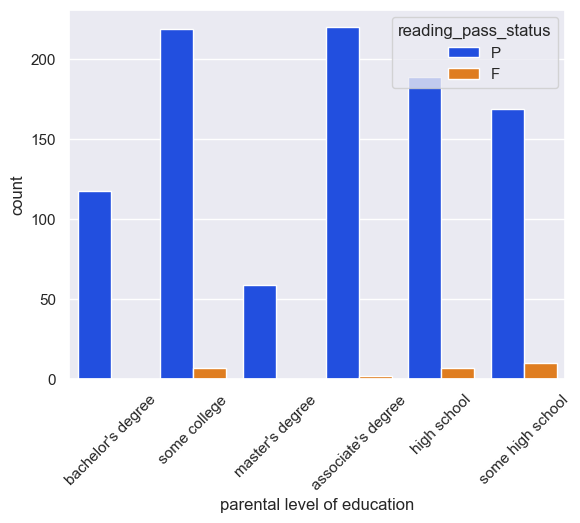

In [17]:
sns.countplot(x = 'parental level of education', data = df, hue = 'reading_pass_status', palette = 'bright')
plt.xticks(rotation = 45)
plt.show()

#### Passing (Blue Bars):
* Dominant: Blue bars are huge for every category. Almost everyone passes reading.
* Largest Groups: "Some college" and "Associate's degree" have the most students passing (over 200 each).
* Smallest Group: "Master's degree" has the fewest students (around 60), but they all pass.
#### Failing (Orange Bars):
* Master's Degree: Zero failures (no orange bar visible).
* Most Failures: "Some high school" has the tallest orange bar (most failures).
* High School: Also has a visible number of failures compared to higher education groups.

Let us explore writing score

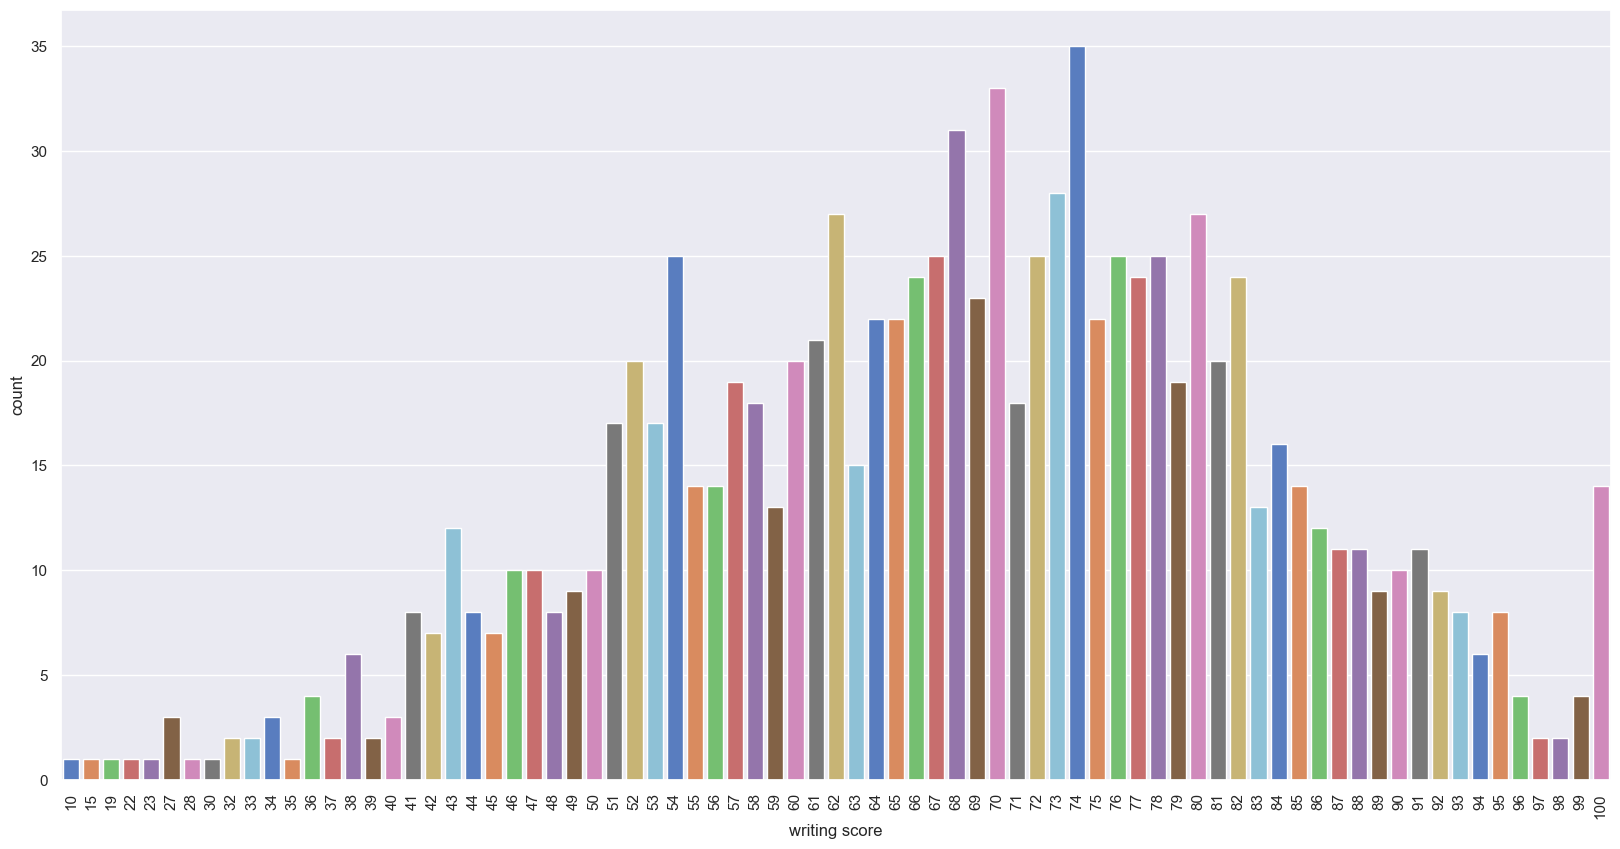

In [18]:
plt.figure(figsize= (20, 10))
sns.countplot(x = 'writing score', data = df, palette= 'muted', hue = 'writing score', legend= False)
plt.xticks(rotation = 90)
plt.show()

* Writing seems easiest: Comparing the peaks, Math peaked at ~65, Reading at ~72, and Writing at ~74. Students generally perform best in Writing.
* Consistent performance: The distribution is smooth, meaning the test effectively measured a range of abilities

How many students passed writing?

In [19]:
df['writing_pass_status'] = np.where(df['writing score'] < passmark, 'F', 'P')
df.writing_pass_status.value_counts().reset_index()

,writing_pass_status,count
0,P,968
1,F,32


* Very high pass rate: 96.8% of students passed writing
* Small fail group: Only 32 students (3.2%) failed
* Comparison: Writing pass rate (96.8%) is between Math (96%) and Reading (97.4%)

In [41]:
is_passed = df.groupby('parental level of education')['writing_pass_status'] \
    .value_counts().reset_index() \
    .sort_values(by='count', ascending=False) \
    .reset_index(drop=True)
is_passed['pass_rates'] = is_passed['count'] / is_passed.groupby('parental level of education')['count'].transform('sum') * 100
is_passed.style.background_gradient(cmap = 'Greens', subset = ['count', 'pass_rates'])

,parental level of education,writing_pass_status,count,pass_rates
0,associate's degree,P,219,98.648649
1,some college,P,217,96.017699
2,high school,P,187,95.408163
3,some high school,P,170,94.972067
4,bachelor's degree,P,116,98.305085
5,master's degree,P,59,100.000000
6,some college,F,9,3.982301
7,some high school,F,9,5.027933
8,high school,F,9,4.591837
9,associate's degree,F,3,1.351351


* Extremely high success: Every single education group passes writing at 95% or higher.
* Perfect score group: Students with master's-educated parents had a 100% pass rate.
* Tiny gap: The difference between the highest (100%) and lowest (~95%) groups is only 5%.
* Rare failures: Only 2–9 students failed per group, showing writing struggles are uncommon across all backgrounds.

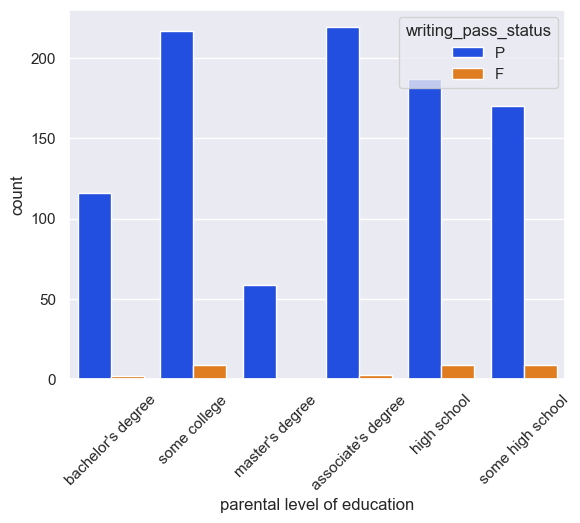

In [21]:
sns.countplot(x = 'parental level of education', data = df, hue = 'writing_pass_status', palette = 'bright')
plt.xticks(rotation = 45)
plt.show()

#### Passing (Blue Bars):
* Dominant: The blue bars are huge for every single category. Almost all students pass writing.
* Largest Groups: "Some college" and "Associate's degree" have the most students passing (over 200 each).
#### Failing (Orange Bars):
* Master's Degree: Zero failures (no orange bar visible).
* Associate's Degree: Almost zero failures (tiny orange sliver).
* Most Failures: "Some high school" and "High school" have the tallest orange bars, meaning these groups struggle slightly more than the others.

let us check 'how many students passed in all the subjects?'

In [22]:
df['over_all_pass_status'] = df.apply(lambda x : 'F' if x['math_pass_status'] == 'F' or 
                                    x['reading_pass_status'] == 'F' or x['writing_pass_status'] == 'F' else 'P', axis =1)

df.over_all_pass_status.value_counts().reset_index()

,over_all_pass_status,count
0,P,949
1,F,51


1.Very high overall pass rate: 94.9% of students passed all subjects\
2.Small fail group: Only 51 students (5.1%) failed at least one subject\
3.Comparison: Overall pass rate (94.9%) is slightly lower than individual subjects:
*  Reading: 97.4%
*  Writing: 96.8%
*  Math: 96.0%

In [42]:
is_passed = df.groupby('parental level of education')['over_all_pass_status'] \
    .value_counts().reset_index() \
    .sort_values(by='count', ascending=False) \
    .reset_index(drop=True)
is_passed['pass_rates'] = is_passed['count'] / is_passed.groupby('parental level of education')['count'].transform('sum') * 100
is_passed.style.background_gradient(cmap = 'Greens', subset = ['count', 'pass_rates'])

,parental level of education,over_all_pass_status,count,pass_rates
0,associate's degree,P,217,97.747748
1,some college,P,216,95.575221
2,high school,P,180,91.836735
3,some high school,P,163,91.061453
4,bachelor's degree,P,114,96.610169
5,master's degree,P,59,100.000000
6,some high school,F,16,8.938547
7,high school,F,16,8.163265
8,some college,F,10,4.424779
9,associate's degree,F,5,2.252252


* Perfect pass record: Students with Master's-educated parents had 0 failures (100% pass rate).
* Clear but modest gap: Higher parental education links to higher pass rates, but the difference between the highest (100%) and lowest (~91%) is only ~9%.
* Strong baseline across all groups: Even students whose parents only completed some high school still pass at 91.1%.
* Degrees perform well: Both Associate's and Bachelor's groups exceed 96% pass rates, showing consistent success.

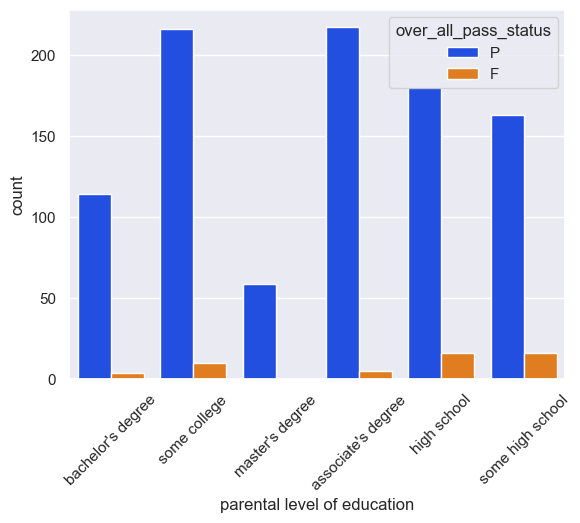

In [24]:
sns.countplot(x = 'parental level of education', data = df, hue = 'over_all_pass_status', palette = 'bright')
plt.xticks(rotation = 45)
plt.show()

#### Passing (Blue Bars):
* Dominant: Blue bars are huge for every category. Almost everyone passes overall.
* Largest Groups: "Some college" and "Associate's degree" have the most students passing (over 200 each).
* Smallest Group: "Master's degree" has the fewest students (around 60), but they all pass.
#### Failing (Orange Bars):
* Master's Degree: Zero failures (no orange bar visible).
* Associate's Degree: Almost zero failures (tiny orange sliver).
* Most Failures: "High school" and "Some high school" have the tallest orange bars, meaning these groups struggle the most compared to the others.

Find the percntage of marks

In [25]:
df['total_marks'] = df['math score'] + df['reading score'] + df['writing score']
df['Percentage'] = df['total_marks'] / 3

In [43]:
percentage = df.groupby('parental level of education')['Percentage'] \
    .value_counts().reset_index() \
    .sort_values(by='count', ascending=False) \
    .reset_index(drop=True)
df['Percentage'] = df['Percentage'].round(2)
percentage.style.background_gradient(cmap = 'Greens', subset = ['count'])

,parental level of education,Percentage,count
0,associate's degree,77.330000,8
1,associate's degree,71.330000,8
2,some college,74.330000,8
3,associate's degree,68.670000,5
4,high school,66.000000,5
5,high school,52.670000,5
6,some college,82.330000,5
7,some high school,57.670000,5
8,some high school,73.330000,5
9,associate's degree,69.000000,4


* Associate's degree and some college parents have the most students
* Master's degree parents have the fewest students
* All education levels show both high and low performers
* Lowest percentages tend to cluster in "high school" and "some high school" groups

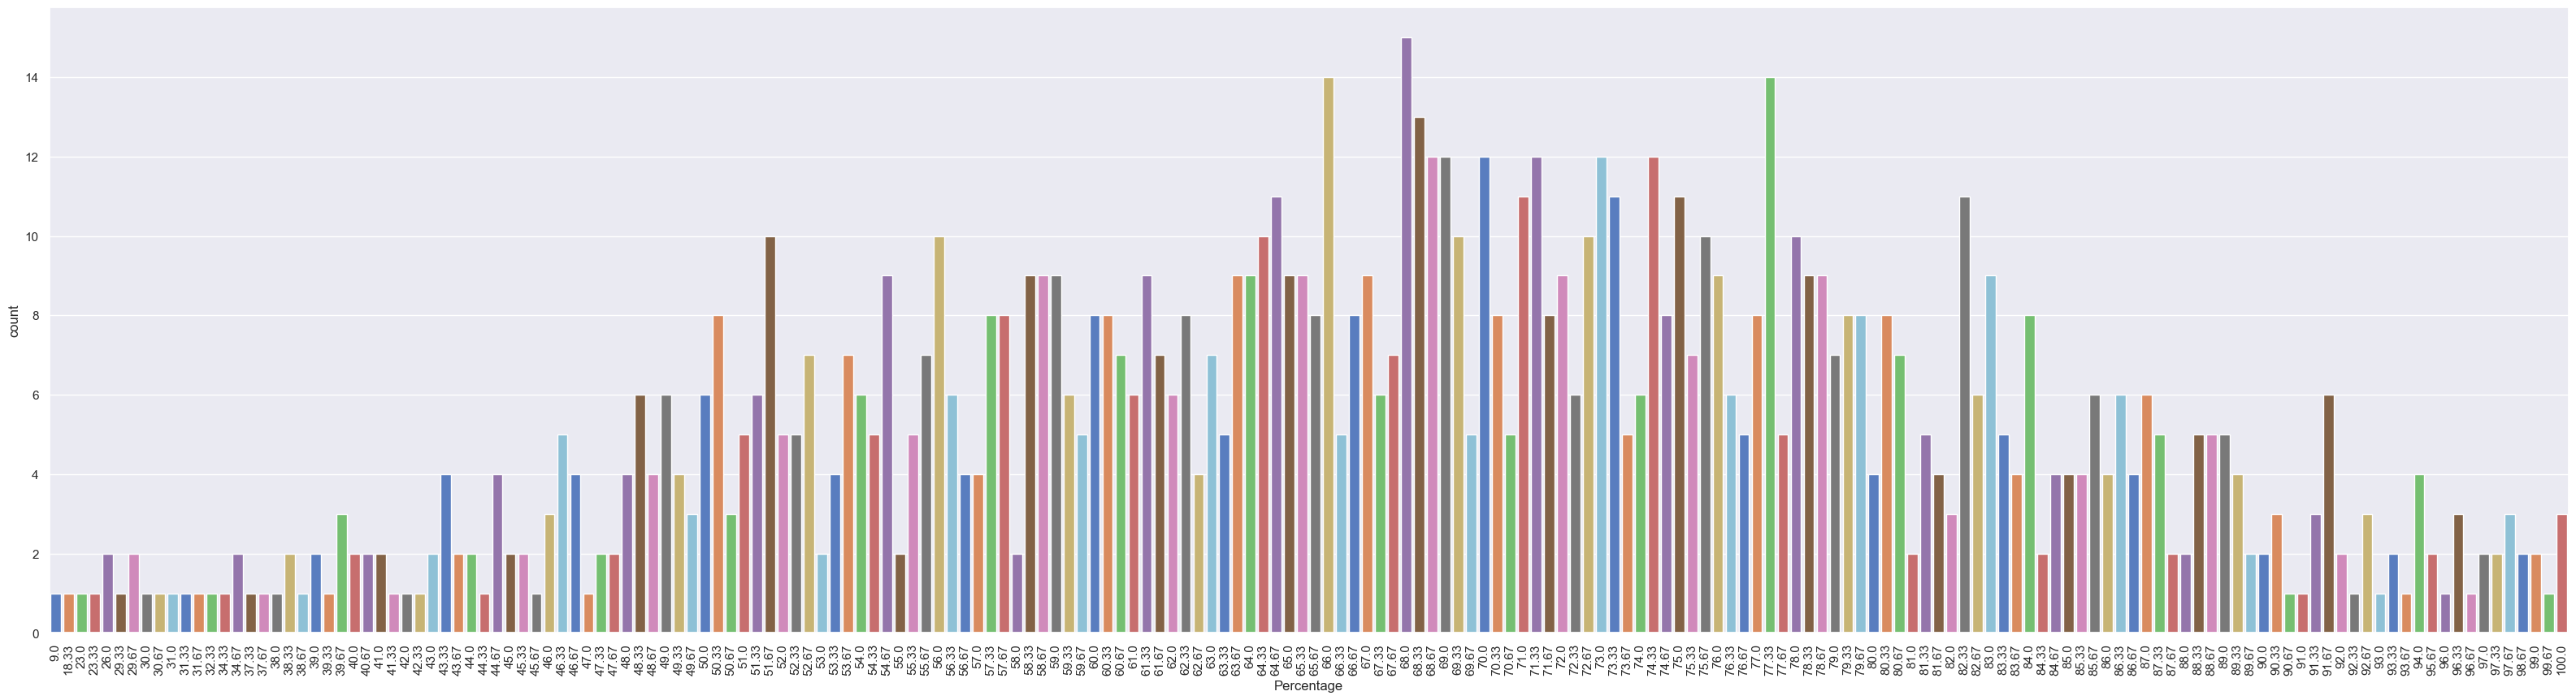

In [28]:
plt.figure(figsize= (40, 10))
sns.countplot(x = 'Percentage', data = df, palette= 'muted', hue = 'Percentage', legend= False)
plt.xticks(rotation = 90)
plt.show()

Let us assign the grades\
Grading\
above 80 = A Grade\
70 to 80 = B Grade\
60 to 70 = C Grade\
50 to 60 = D Grade\
40 to 50 = E Grade\
below 40 = F Grade ( means Fail )

In [46]:
def get_grad(percentage, over_all_pass_status):
    if over_all_pass_status == 'F':
        return 'F'
    if percentage >= 80:
        return 'A'
    if percentage >= 70:
        return 'B'
    if percentage >= 60:
        return 'C'
    if percentage >= 50:
        return 'D'
    if percentage >= 40:
        return 'E'
    else:
        return 'F'

df['Grade'] = df.apply(lambda x : get_grad(x['Percentage'], x['over_all_pass_status']), axis = 1)

Grade = df.Grade.value_counts().reset_index()
Grade['rates'] = Grade['count'] / Grade['count'].sum() * 100
Grade.style.background_gradient(cmap = 'Greens', subset = ['count', 'rates'])

,Grade,count,rates
0,B,261,26.100000
1,C,256,25.600000
2,A,198,19.800000
3,D,178,17.800000
4,E,56,5.600000
5,F,51,5.100000


* Most common grades: B and C — together they make up ~52% of students (the "average" group)
* High performers: A grade = ~20% of students
* Lower performers: D, E, F combined = ~28% of students
* Failing grade (F): Only 5.1% — matches the overall fail rate we saw earlie

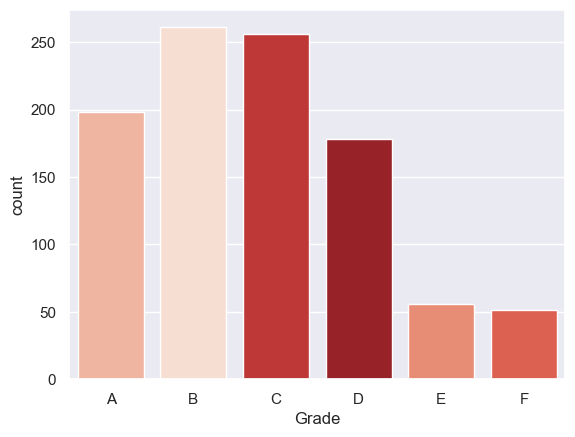

In [30]:
sns.countplot(x="Grade",
              data = df,
              order=['A','B','C','D','E','F'],
              palette="Reds",
              hue = 'Grade')
plt.show()

* The "Average" dominates: Grades B and C make up the majority of students (over 500 combined).
* High success rate: Grades A, B, and C account for the vast majority of the class (approx. 700+ students).
* Sharp drop-off: There is a big drop in students between Grade D and Grade E.
* Few failures: Very few students received an F.

In [31]:
percentage = df.groupby('parental level of education')['Grade'] \
    .value_counts().reset_index() \
    .sort_values(by='count', ascending=False) \
    .reset_index(drop=True)
percentage.style.background_gradient(cmap = 'Greens', subset = ['count'])

,parental level of education,Grade,count
0,some college,C,63
1,some college,B,62
2,associate's degree,B,59
3,high school,C,55
4,associate's degree,C,53
5,associate's degree,A,51
6,some college,A,46
7,high school,B,45
8,some high school,B,44
9,high school,D,42


* Higher parental education = Better grades: Master's and Bachelor's groups have more A's and B's
* Lower parental education = More D's and F's: High school and some high school groups struggle more
* Most common grade overall: C and B across all education levels
* Master's degree advantage: Highest proportion of A grades

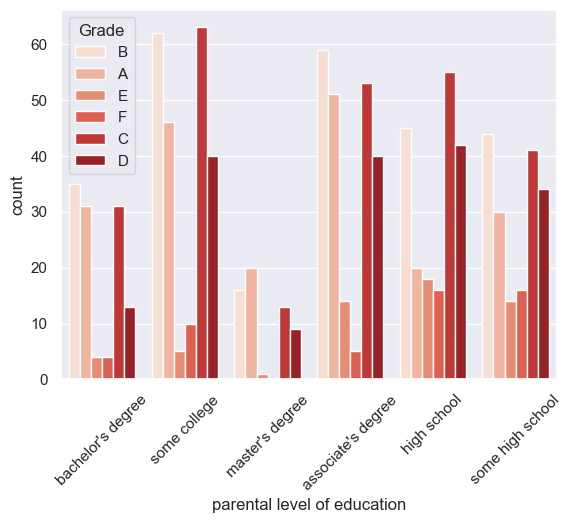

In [49]:
sns.countplot(x = 'parental level of education', data = df, hue = 'Grade', palette = 'Reds')
plt.xticks(rotation = 45)
plt.show()

* Parental Education Matters: As parental education goes up (Master's/Bachelor's), student grades go up (more A's and B's).
* The "C" Trap: For parents with lower education levels (High School/Some High School), C is the most common grade.
* Grade A Gap: It is much harder to get an A if your parents only have a high school education compared to a master's degree.